<a href="https://colab.research.google.com/github/Lawau/simple-proxy/blob/dev/Booking_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pré Processamento

Importação

In [3]:
import pandas as pd
import numpy as np
import graphviz

Leitura

In [4]:
df_booking = pd.read_csv('booking.csv')
display(df_booking.dtypes)

,0
Booking_ID,object
number of adults,int64
number of children,int64
number of weekend nights,int64
number of week nights,int64
type of meal,object
car parking space,int64
room type,object
lead time,int64
market segment type,object


In [5]:
atributos = df_booking.drop(columns='booking status')
resposta = df_booking['booking status']

**Transformação Númerica

In [6]:
from re import A
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, StandardScaler

prepoc = ColumnTransformer(transformers=[
    ('categorica', OrdinalEncoder(), make_column_selector(dtype_include=object))],
    remainder='passthrough', verbose_feature_names_out = False)

atributos_numericos = prepoc.fit_transform(atributos) #transforma texto em numero
atributos = pd.DataFrame(atributos_numericos, columns=atributos.columns) #traz como df numerico/categorizado

escala_min_max = ColumnTransformer(transformers=[
    ('numerico', MinMaxScaler(), make_column_selector(dtype_include='float64'))
])

atributos = escala_min_max.fit_transform(atributos)  #escalonamento normalizado
# escala_stand = ColumnTransformer(transformers=[
#     ('numerico', StandardScaler(), make_column_selector(dtype_include='float64'))
# ])
# atributos = escala_stand.fit_transform(atributos)   #escalonamento padronizado
print(type(atributos))


<class 'numpy.ndarray'>


#PCA no Python

##PCA Manual

In [ ]:
# matriz_cov = np.cov(atributos, rowvar=False)

###Encontrando os Componentes Principais e as Forças

In [ ]:
# autovalores, autovetores = np.linalg.eigh(matriz_cov)

###Explicação da variância

In [ ]:
# var_pct = {}

# for x in autovalores:
#   var_pct[len(var_pct)] = (round(x/sum(autovalores)*100, 2))

# var_pct = dict(sorted(var_pct.items(), key=lambda item: item[1], reverse=True))
# print(var_pct)
# y = 0
# for chave, valor in var_pct.items():
#   y += valor
#   print(y, chave)



In [ ]:
# pcas = {}

# for chave, valor in var_pct.items():
#   pcas["pca" + str(chave)] = autovetores[::, chave]

# print(pcas)

###Seleção de linhas

In [ ]:
PC1 = autovetores[::, 0]
PC2 = autovetores[::, 1]
PCs = np.array([PC1,PC2]).T
print(PCs)

[[ 5.73976773e-04  7.86643965e-04]
 [-3.64664314e-04  9.81500769e-05]
 [-2.33592310e-03  1.88716055e-03]
 [ 1.34436000e-02  6.82158989e-03]
 [-2.78631769e-03 -2.22136520e-04]
 [ 6.20556365e-03  1.11207959e-03]
 [ 2.60079397e-03 -2.83602274e-03]
 [-2.63337094e-03  9.94695002e-04]
 [-6.24418851e-04  1.77773219e-03]
 [-2.08395328e-03 -2.00616659e-03]
 [ 9.46886452e-04  9.51700451e-04]
 [-2.22879662e-02  1.27053758e-01]
 [-6.80446863e-01 -7.28406463e-01]
 [ 7.32207708e-01 -6.73019569e-01]
 [ 4.89987380e-03 -1.56618595e-02]
 [-9.53555259e-03  3.40584815e-03]]


###Transformação dos Dados Originais

In [ ]:
#atributos_2d = np.dot(atributo, PCs)

##PCA com Lib

In [7]:
from sklearn.decomposition import PCA

n_features = atributos.shape[1]

atributos_pca = {}

# Aplica PCA para 1 até n_features componentes
for x in range(1, n_features + 1):
    pca = PCA(n_components=x)
    atributos_pca[f"atributos_pca{x}"] = pca.fit_transform(atributos)

print(atributos_pca)



{'atributos_pca1': array([[-0.16646388],
       [ 0.85445536],
       [-0.10942719],
       ...,
       [-0.25558027],
       [-0.16620539],
       [-0.25772468]]), 'atributos_pca2': array([[-0.16646388, -0.05118123],
       [ 0.85445536, -0.15000835],
       [-0.10942719, -0.2799849 ],
       ...,
       [-0.25558027,  0.38498015],
       [-0.16620539,  0.19289568],
       [-0.25772468,  0.53385609]]), 'atributos_pca3': array([[-0.16646388, -0.05118123, -0.65485356],
       [ 0.85445536, -0.15000835, -0.53286716],
       [-0.10942719, -0.2799849 , -0.43491269],
       ...,
       [-0.25558027,  0.38498015,  0.27118242],
       [-0.16620539,  0.19289568,  0.52576628],
       [-0.25772468,  0.53385609,  0.09652805]]), 'atributos_pca4': array([[-0.16646388, -0.05118123, -0.65485356, -0.2325246 ],
       [ 0.85445536, -0.15000835, -0.53286716,  0.10113356],
       [-0.10942719, -0.2799849 , -0.43491269, -0.07004319],
       ...,
       [-0.25558027,  0.38498015,  0.27118242,  0.41686239],

## Gráfico Cotovelo

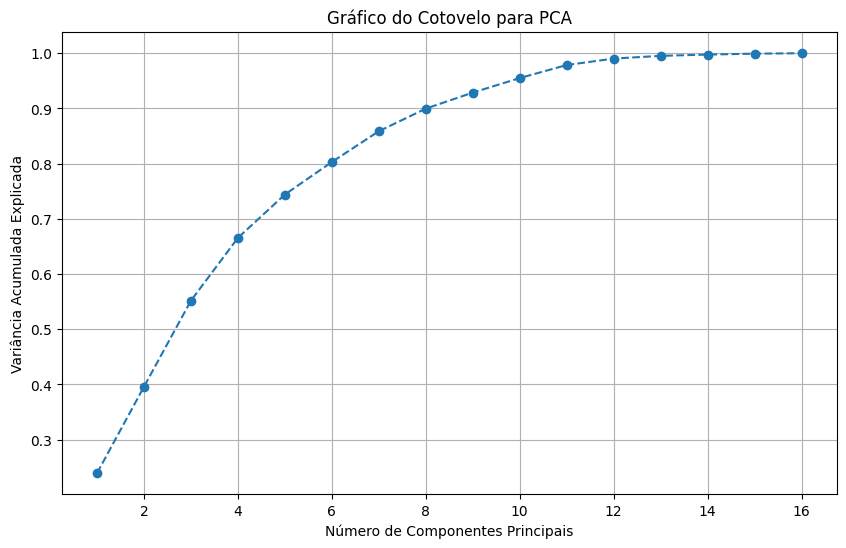

In [ ]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# Quantos atributos temos
n_features = atributos.shape[1]

# Cria e ajusta o PCA com todos os componentes possíveis
pca = PCA(n_components=n_features)
pca.fit(atributos)

# Variância explicada por cada componente
explained_variance = pca.explained_variance_ratio_

# Variância acumulada
cumulative_variance = explained_variance.cumsum()

# Plotando
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_features + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Gráfico do Cotovelo para PCA')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Acumulada Explicada')
plt.grid(True)
plt.show()


In [ ]:
n_componentes_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Número de componentes para explicar 95% da variância: {n_componentes_95}")

Número de componentes para explicar 95% da variância: 10


#   Modelos


## Separação Treino e teste

In [8]:
from sklearn.model_selection import train_test_split

atributos_treino = {}
atributos_teste = {}
respostas_treino = {}
respostas_teste = {}
for chave, valor in atributos_pca.items():
  atributos_treino[chave], atributos_teste[chave], respostas_treino[chave], respostas_teste[chave] = train_test_split(valor, resposta, test_size=0.25, random_state=42)

## Naive Bayes

### Modelo

In [ ]:
#Criação do modelo
from sklearn.naive_bayes import GaussianNB

naive_bayes_modelos = {}

#treino - fit
for chave, valor in atributos_treino.items():
  modelo = GaussianNB()
  naive_bayes_modelos[chave] = modelo.fit(valor, respostas_treino[chave])

print()
#teste - predict
respostas_modelo_naive_bayes = {}

for chave, valor in atributos_teste.items():
  respostas_modelo_naive_bayes[chave] = naive_bayes_modelos[chave].predict(valor)

print(respostas_modelo_naive_bayes)



{'atributos_pca1': array(['Not_Canceled', 'Not_Canceled', 'Not_Canceled', ...,
       'Not_Canceled', 'Not_Canceled', 'Not_Canceled'], dtype='<U12'), 'atributos_pca2': array(['Not_Canceled', 'Not_Canceled', 'Not_Canceled', ...,
       'Not_Canceled', 'Not_Canceled', 'Not_Canceled'], dtype='<U12'), 'atributos_pca3': array(['Not_Canceled', 'Not_Canceled', 'Not_Canceled', ...,
       'Not_Canceled', 'Not_Canceled', 'Not_Canceled'], dtype='<U12'), 'atributos_pca4': array(['Not_Canceled', 'Not_Canceled', 'Not_Canceled', ...,
       'Not_Canceled', 'Not_Canceled', 'Not_Canceled'], dtype='<U12'), 'atributos_pca5': array(['Not_Canceled', 'Not_Canceled', 'Not_Canceled', ...,
       'Not_Canceled', 'Not_Canceled', 'Not_Canceled'], dtype='<U12'), 'atributos_pca6': array(['Not_Canceled', 'Not_Canceled', 'Not_Canceled', ...,
       'Not_Canceled', 'Not_Canceled', 'Not_Canceled'], dtype='<U12'), 'atributos_pca7': array(['Canceled', 'Not_Canceled', 'Not_Canceled', ..., 'Not_Canceled',
       'Not_Ca

### Métricas

In [ ]:
from sklearn.metrics import accuracy_score

naive_bayes_metrics = {}
for chave, valor in respostas_modelo_naive_bayes.items():
  naive_bayes_metrics[chave] = accuracy_score(respostas_teste[chave], valor)

naive_bayes_metrics = dict(sorted(naive_bayes_metrics.items(), key=lambda item: item[1], reverse=True))
print(naive_bayes_metrics)

best_naive_bayes_metric = dict([next(iter(naive_bayes_metrics.items()))])
print(best_naive_bayes_metric)


best_naive_bayes = {chave: naive_bayes_modelos[chave] for chave in best_naive_bayes_metric.keys()}
print(best_naive_bayes)
#standalization = 0.7314814814814815 - pca13
#normalization = 0.7619047619047619 - pca13

{'atributos_pca13': 0.7619047619047619, 'atributos_pca14': 0.761794532627866, 'atributos_pca6': 0.7581569664902998, 'atributos_pca12': 0.7559523809523809, 'atributos_pca11': 0.7535273368606702, 'atributos_pca10': 0.750110229276896, 'atributos_pca7': 0.7477954144620811, 'atributos_pca5': 0.7431657848324515, 'atributos_pca9': 0.7423941798941799, 'atributos_pca8': 0.7376543209876543, 'atributos_pca1': 0.6689814814814815, 'atributos_pca2': 0.6689814814814815, 'atributos_pca3': 0.6689814814814815, 'atributos_pca4': 0.6689814814814815, 'atributos_pca15': 0.6290784832451499, 'atributos_pca16': 0.5559964726631393}
{'atributos_pca13': 0.7619047619047619}
{'atributos_pca13': GaussianNB()}


## Gini e Entropy (FAZENDO)

### Modelo

In [ ]:
#Criação do modelo
from sklearn.tree import DecisionTreeClassifier

arvores = {}
for chave, valor in atributos_treino.items():
  arvore = DecisionTreeClassifier()
  arvores[chave] = arvore.cost_complexity_pruning_path(valor, respostas_treino[chave])


jardineiros = {}
for chave, ccp in arvores.items():
  jardineiro = ccp['ccp_alphas'][::-1] #tira o último porque ele corta a árvore toda
  jardineiros[chave] = list(jardineiro[jardineiro >= 0]) #tira valores negativos
print(jardineiros["atributos_pca1"])


### Métricas

In [ ]:
from sklearn.metrics import accuracy_score

arvores_jardineiros = {}
accurácias_teste_knn = {}

for chave, valor in jardineiros.items():
  for jardineiro in valor:
    tree = DecisionTreeClassifier(ccp_alpha = jardineiro)
    tree.fit(atributos_treino[chave], respostas_treino[chave])

    arvores_jardineiros[chave]= {jardineiro: tree}
    result_teste = tree.predict(atributos_teste[chave])

    perf_teste = accuracy_score(respostas_teste[chave], result_teste)

    accurácias_teste_knn[chave] = {jardineiro: perf_teste}


print(accurácias_teste_knn.head(2))
print(arvores_jardineiros.head(2))
# melhor_acc_knn = dict(sorted(accurácias_teste_knn.items(), key=lambda item: item[1], reverse=True))
# melhor_modelo = {arvores[acc_teste.index(max(acc_teste))]: max(acc_teste)}

# print("Maior acurácia: ", max(acc_teste))

# print("Melhor árvore: ", melhor_modelo)

KeyboardInterrupt: 

In [10]:
from sklearn.model_selection import GridSearchCV

arvores_jardineiros = {}
accurácias_teste_knn = {}

for chave, valor in jardineiros.items():
  param = {
      'criterion': ['gini', 'entropy'],
      'ccp_alpha': [i for i in valor]
  }
  tree = DecisionTreeClassifier()
  grid = GridSearchCV(estimator = tree, param_grid = param, scoring = 'accuracy',n_jobs=-1)
  grid.fit(atributos_treino[chave], respostas_treino[chave])

  arvores_jardineiros[chave]= {jardineiro: grid}
  result_teste = grid.predict(atributos_teste[chave])

  perf_teste = accuracy_score(respostas_teste[chave], result_teste)

  accurácias_teste_knn[chave] = perf_teste


print(accurácias_teste_knn.head(2))
print(arvores_jardineiros.head(2))
# melhor_acc_knn = dict(sorted(accurácias_teste_knn.items(), key=lambda item: item[1], reverse=True))
# melhor_modelo = {arvores[acc_teste.index(max(acc_teste))]: max(acc_teste)}

# print("Maior acurácia: ", max(acc_teste))

# print("Melhor árvore: ", melhor_modelo)

KeyboardInterrupt: 

## KNN

### Modelo

In [ ]:
#Criação do modelo
from sklearn.neighbors import KNeighborsClassifier


param_knn = {
    'n_neighbors': range(1,50)      #única coisa realmente importante que é legal variar
}

knn_modelos = {}
for chave, valor in respostas_treino.items():
  knn = KNeighborsClassifier()
  grid = GridSearchCV(estimator = knn, param_grid = param_knn, scoring = 'accuracy',n_jobs=-1)

  grid.fit(atributos_treino[chave], valor)

  knn_modelos[chave] = grid #[grid.best_score, grid.best_params]



### Métricas

In [ ]:
knn_metrics = {}
for chave, valor in knn_modelos.items():
  resposta_grid = valor.predict(atributos_teste[chave])
  grid_metric = accuracy_score(respostas_teste[chave], resposta_grid)

  knn_metrics[chave] = grid_metric

knn_metrics = dict(sorted(knn_metrics.items(), key=lambda item: item[1], reverse=True))
best_knn_accuracy = dict([next(iter(knn_metrics.items()))])
print(best_knn_accuracy)

best_knn = {chave: knn_modelos[chave] for chave in best_knn_accuracy.keys()}
print(best_knn)
#standalization = 0.7314814814814815 - pca13
#normalization = 0.7619047619047619 - pca13